# Understanding Optimisation

**Learning Outcomes**
1. Understand how an optimiser seeks to minimise a loss function by following a direction opposite to its gradient in 1d and 2d cases
2. Form intuition on the optimisation process for 1d and 2d attributes dataset in order to help understand the same concepts for M dimension space.

In this exercise you will look at minimising the sum of squared errors SSE of a set of clusters. We start off with examples that minimise 1d and 2d functions. Then we look into minimising SSE for datasets of one cluster (entire dataset), two clusters both with 1 attribute. Then we move to datasets with 2 attributes. We also look at clusters with different shapes.


## Minimising a Simple Function in 1D

In [1]:
%matplotlib inline
from IPython.core.display import display, HTML
display(HTML('<style>.container {width: 85% !important}</style>'))

In [2]:
import matplotlib.pyplot as plt
import numpy as np

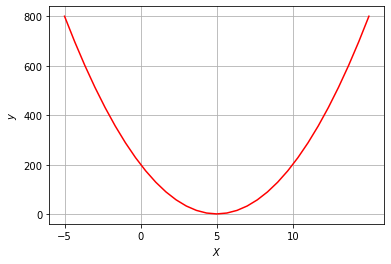

In [3]:
a = 5 #  change this to any value you like 
x = np.linspace(a-10, a+10,31) # number of points must be odd otherwise the samples on x will miss the minimum
w0 = 1 # change this to any value you like 
w1 = 8 # change this to any value you like 

y  = w0 + w1*(x-a)**2

# non essential stuff to make the plot aesthetically better
plt.xlabel('$X$')
plt.ylabel('$y$')

plt.xticks(np.arange(x.min(), x.max(), step=5))
plt.yticks(np.arange(y.min()-1, y.max(), step=200))

plt.plot(x, y, '-r')
plt.grid()




Try different values of a to see that a is always the minimiser for this function

In [4]:
x[np.argmin(y)]==a

True

## Minimising a Surface Function in 2D

/var/folders/5s/t5nyc5mx7gd0_0g56wdmpgmrq78pqs/T/ipykernel_64345/4237017994.py:9: MatplotlibDeprecationWarning: Calling gca() with keyword arguments was deprecated in Matplotlib 3.4. Starting two minor releases later, gca() will take no keyword arguments. The gca() function should only be used to get the current axes, or if no axes exist, create new axes with default keyword arguments. To create a new axes with non-default arguments, use plt.axes() or plt.subplot().
  ax  = fig.gca(projection='3d')


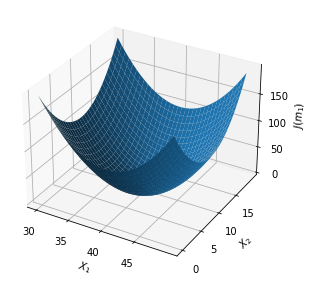

In [5]:
import matplotlib.pyplot as plt
import numpy as np

m =[40,10] # this is a centroid in 2d space
a = m[0]   # 40  # change this to any value
b = m[1]   # 10  # change this to any value

fig = plt.figure()
ax  = fig.gca(projection='3d')
step = .3 # try 3 instead to see the effect
x = np.arange(a-10, a+10, step)
y = np.arange(b-10, b+10, step)
X, Y = np.meshgrid(x, y)

Z = (X-a)**2 + (Y-b)**2  # SSE sum of squared distances

# Plot the surface.
surf = ax.plot_surface(X, Y, Z)

ax.set_xticks(np.arange(x.min(), x.max(), step=5))
ax.set_yticks(np.arange(y.min(), y.max(), step=5))
ax.set_zticks(np.arange(Z.min(), Z.max(), step=50))
ax.set_xlabel('$X_1$')
ax.set_ylabel('$X_2$')
ax.set_zlabel('$J(m_1)$')
plt.tight_layout()
plt.savefig('figures/2dobjectiveMinmisation.png')

In [6]:
eps = 0.01
ind = round(np.argmin(Z)/(len(x)+1))
#print(len(x),ind)
#X[ind,ind]==a and Y[ind,ind]==b
x[ind]-a < eps and y[ind]- b <eps


True

## Minimising the SSE Function for a Cluster

### One cluster case

In the following code 

1. we create a simple one cluster dataset and then 
2. we calculate its SSE with respect to several centroids. 
3. we then show that the minimal value of the SSE corresponds with the mean of the cluster set.

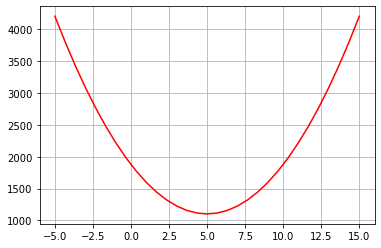

In [7]:
n = 31 # number of points must be odd otherwise the samples on x will miss the minimum
a = 5  # this is center of the dataset, you can change this to any value you like 

x = np.linspace(a-10, a+10, n)          # this is our simple dataset
mu= x.mean()

# m are the search space for the centroid, it can take any value in the dataset range
# we will prove that the best value is the mean of the dataset
m   = np.linspace(x.min(), x.max(), n)  
SSE = np.zeros(m.shape)

for i, mi in enumerate(m):
    SSE[i] = ((x-mi)**2).sum()

plt.plot(x, SSE, '-r')
plt.grid()

Try different values of 'a' to see that 'a' is always the minimiser for this function

Now, we want to obtain the m value that makes SSE minimal

In [8]:
print(SSE.min())
print(SSE.argmin())
print(m[SSE.argmin()])

1102.2222222222222
15
5.0


Now the moment of truth :-). Our m value that minimises the SSE must correspond with the mean of the dataset

In [9]:

x.mean() == m[SSE.argmin()]


True

### Two cluster case with uniformed distribution

In the following code 

1. we create a simple two clusters dataset and then 
2. we calculate the SSE for each cluster with respect to several centroids
3. we then show that the minimal value of the SSEs corresponds with the mean of each cluster set

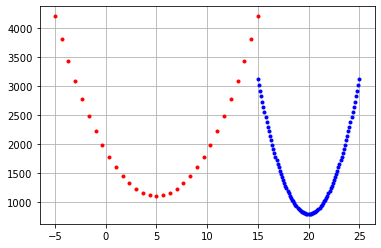

In [10]:
n = 31 # number of points must be odd otherwise the samples on x will miss the minimum
a = 5  # this is center of the dataset, you can change this to any value you like 

cluster1 = np.linspace(a-10, a+10, n)          # first  cluster uniformally distributed
cluster2 = np.linspace(a+10, a+20, n*3)        # second cluster uniformally distributed and has more data points

# m1 and m2 are the search spaces for the centroids in cluster 1 and 2, it can take any value in the cluster range
# the bigger the search space the more likely we will land on a vlaue close to the mean
# we will prove that the best value is the mean of the dataset
m1   = np.linspace(cluster1.min(), cluster1.max(), n)  
m2   = np.linspace(cluster2.min(), cluster2.max(), n*3)  

SSE1= np.zeros(m1.shape)
SSE2= np.zeros(m2.shape)

for i, mi in enumerate(m1):
    SSE1[i] = ((cluster1-mi)**2).sum()

for i, mi in enumerate(m2):
    SSE2[i] = ((cluster2-mi)**2).sum()

plt.plot(m1, SSE1, '.r')
plt.plot(m2, SSE2, '.b')
plt.grid()


In [11]:
print('----Cluster 1---------')
print(SSE1.min())
print(SSE1.argmin())
print(m1[SSE1.argmin()])
print(cluster1.mean())

print('----Cluster 2---------')
print(SSE2.min())
print(SSE2.argmin())
print(m2[SSE2.argmin()])
print(cluster2.mean())

----Cluster 1---------
1102.2222222222222
15
5.0
5.0
----Cluster 2---------
791.8478260869565
46
20.0
20.0


In [12]:
cluster1.mean() == m1[SSE1.argmin()] and cluster2.mean() == m2[SSE2.argmin()]

True

### Two Clusters case with a normal distribution

This time we need to be careful in terms of exact equality as the centroids search space is uniformed while the input space is normally distributed. So the centroids will be close to the mean but not exactly the same. 

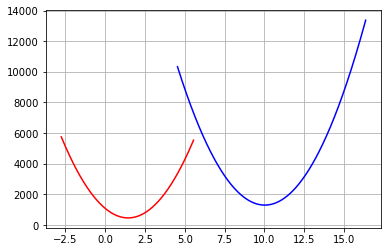

In [13]:
n = 301 # number of points must be odd otherwise the samples on x will miss the minimum
a = 5  # this is centre of the dataset, you can change this to any value you like 

mu1, sigma1 = 1.5, 1.2
mu2, sigma2 =  10, 2.0
cluster1  = np.random.normal(mu1,sigma1,n)
cluster2  = np.random.normal(mu2,sigma2,n)

# m1 and m2 are the search spaces for the centroids in cluster 1 and 2, it can take any value in the cluster range
# the bigger the search space the more likely we will land on a value close to the mean
# we will prove that the best value is the mean of the dataset
m1   = np.linspace(cluster1.min(), cluster1.max(), n*10)  
m2   = np.linspace(cluster2.min(), cluster2.max(), n*10)  

SSE1= np.zeros(m1.shape)
SSE2= np.zeros(m2.shape)

for i, mi in enumerate(m1):
    SSE1[i] = ((cluster1-mi)**2).sum()

for i, mi in enumerate(m2):
    SSE2[i] = ((cluster2-mi)**2).sum()

plt.plot(m1, SSE1, '-r')
plt.plot(m2, SSE2, '-b')
plt.grid()

In [14]:
print('----Cluster 1---------')
print(SSE1.min())
print(SSE1.argmin())
print(m1[SSE1.argmin()])
print(cluster1.mean())

print('----Cluster 2---------')
print(SSE2.min())
print(SSE2.argmin())
print(m2[SSE2.argmin()])
print(cluster2.mean())

----Cluster 1---------
457.7510939802746
1520
1.4404595168873877
1.441623648813271
----Cluster 2---------
1294.9874390947898
1396
10.022965966543325
10.021520489374739


In [15]:
eps = 0.005
cluster1.mean() - m1[SSE1.argmin()]< eps and cluster2.mean()-  m2[SSE2.argmin()] < eps

True

### Two clusters with two attributes

In the previous cases, we were dealing with one attribute x for each cluster.

This time we will deal with two cluster and our datasets have two attributes x1 and x2

/var/folders/5s/t5nyc5mx7gd0_0g56wdmpgmrq78pqs/T/ipykernel_64345/1536895460.py:6: RuntimeWarning: covariance is not positive-semidefinite.
  cluster1 = np.random.multivariate_normal(mu1,cov1,n).T # T is for transpose


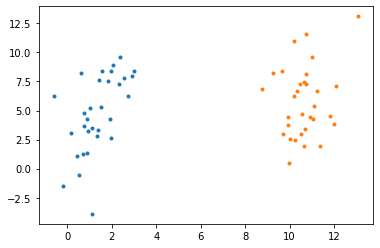

In [16]:
n = 31 # number of points must be odd otherwise the samples on x will miss the minimum
a = 5  # this is centre of the dataset, you can change this to any value you like 

mu1, cov1 = [1.5, 5], [[1, 3], [2, 10]]  # there is a strong correlation between the x and y axis
mu2, cov2 = [10.5, 5], [[1, 0], [0, 10]] # try this no correlation between the x and y axis
cluster1 = np.random.multivariate_normal(mu1,cov1,n).T # T is for transpose
cluster2 = np.random.multivariate_normal(mu2,cov2,n).T # T is for transpose

plt.plot(cluster1[0],cluster1[1],'.') 
plt.plot(cluster2[0],cluster2[1],'.') 

# m10, m11 and m20 and m21 are the search spaces for the centroids in cluster 1 and 2, it can
#take any value in the cluster range the bigger the search space the more likely we will land 
#on a value close to the mean we will prove that the best value is the mean of the dataset
m10  = np.linspace(cluster1[0].min(), cluster1[0].max(), n*10)  
m11  = np.linspace(cluster1[1].min(), cluster1[1].max(), n*10)  

m20  = np.linspace(cluster2[0].min(), cluster2[0].max(), n*10)  
m21  = np.linspace(cluster2[1].min(), cluster2[1].max(), n*10)  

SSE1 = np.zeros((len(m10),len(m11)))
SSE2 = np.zeros((len(m20),len(m21)))

for i, mi in enumerate(m10):
    for j, mj in enumerate(m11):
        m1 = np.c_[mi , mj ].T
        SSE1[i,j] = ((mi -cluster1[0])**2 + (mj -cluster1[1])**2 ).sum()

for i, mi in enumerate(m20):
    for j, mj in enumerate(m21):
        m2 = np.c_[mi , mj].T
        SSE2[i,j] = ((mi -cluster2[0])**2 + (mj -cluster2[1])**2 ).sum()

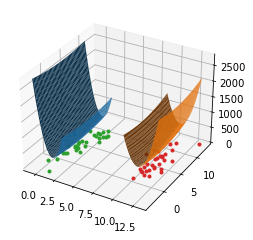

In [17]:
m_10, m_11 = np.meshgrid(m10, m11)
m_20, m_21 = np.meshgrid(m20, m21)

# %matplotlib notebook # uncomment if you want to control the views
fig, ax = plt.subplots(subplot_kw={'projection': '3d'})

surf = ax.plot_surface(m_10, m_11, SSE1)
surf = ax.plot_surface(m_20, m_21, SSE2)
plt.plot(cluster1[0],cluster1[1],'.') 
plt.plot(cluster2[0],cluster2[1],'.') 

In [18]:
print('----Cluster 1---------')
#print(SSE1[0].min(), SSE1[1].min())
i,j = SSE1[0].argmin(), SSE1[1].argmin()
minSSE1 = np.c_[m_10[i,j], m_11[i,j]]
print(minSSE1)
print(cluster1.mean(1))


print('----Cluster 2---------')
#print(SSE2[0].min(), SSE2[1].min())
i,j = SSE2[0].argmin(), SSE2[1].argmin()
minSSE2 = np.c_[m_20[i,j], m_21[i,j]]
print(minSSE2)
print(cluster2.mean(1))


----Cluster 1---------
[[1.70266243 4.75111025]]
[1.34789005 4.73337567]
----Cluster 2---------
[[10.57431857  5.78736218]]
[10.63202414  5.79570774]


Let us check that the min of SSEs correspond with the mean of the clusters

In [19]:
eps = 0.1 # you may need to increase this value if the dataset is small or if the meshgrid is not fine enough
diff1 = cluster1.mean(1) - minSSE1
diff2 = cluster2.mean(1) - minSSE2

diff1.sum()/2 < eps and diff2.sum()/2 < eps

True